# Shot-Based Circuit Simulation

Relaxation changes which bitstrings a quantum circuit produces. We study this
change by preparing a **16-qubit graph state** and sampling its readout at
several damping strengths. Grouping the outcomes by the number of excited qubits
makes the loss of excitation visible without plotting all $2^{16}$ bitstrings.

This guide extends the circuit-readout example in {doc}`quickstart` using the
standard YAQS installation. YAQS evolves a matrix product state (MPS) through
the circuit and samples the final state in the computational basis. Run the
cells in order in a notebook. For a script, use the `if __name__ == "__main__":`
guard shown in {doc}`simulator_initialization`.

## 1. Prepare the circuit and initial state

Start from $|0\rangle^{\otimes16}$, apply a Hadamard gate to each qubit, then
entangle neighboring qubits with CZ gates. These gates change relative phases
without changing computational-basis probabilities, so the ideal readout has
equal probability for every bitstring.

In [1]:
from qiskit import QuantumCircuit

from mqt.yaqs import State

num_qubits = 16
circuit = QuantumCircuit(num_qubits)
circuit.h(range(num_qubits))
for site in range(num_qubits - 1):
    circuit.cz(site, site + 1)
circuit.measure_all()

state = State(num_qubits, initial="zeros")

`State` uses an MPS by default. `shots` requests final computational-basis
sampling, including when a circuit has no explicit measurement gates. YAQS
accepts the terminal measurements above; it does not support measurements
followed by further gates on the measured qubits or classical feedback.

## 2. Set the sampling budget and damping

Each shot produces one bitstring. We use 256 shots per run to keep the example
quick, with the `fast` preset controlling numerical tolerances.

In [2]:
from mqt.yaqs import DigitalSimParams, NoiseModel

params = DigitalSimParams(shots=256, preset="fast", random_seed=7)
damping_rate = 1.5
noise = NoiseModel([
    {"name": "lowering", "sites": [site], "strength": damping_rate}
    for site in range(num_qubits)
])

The `lowering` channel relaxes $|1\rangle$ toward $|0\rangle$. In circuit
simulation, `strength` is a Lindblad rate per unit of gate noise time, rather
than a direct error probability. YAQS applies one unit of noise time after each
gate on two or more qubits, using only noise processes supported entirely on
that gate's qubits. Single-qubit gates and idle sites receive no noise.

Here, each end qubit participates in one CZ gate, while each interior qubit
participates in two. The noise therefore acts during entangling operations,
rather than as a separate readout-error channel. Simulate a transpiled circuit
when its compiled gates should determine the noise opportunities.

`shots` sets the total sample budget and must be supplied explicitly. In a noisy
shots-only run, YAQS uses one stochastic trajectory per shot. The noiseless run
evolves once and samples that final state repeatedly. Setting `num_traj` does
not change a shots-only budget. See {doc}`simulation_parameters` for presets and
the separate roles of shots and trajectories.

## 3. Run the noiseless and noisy cases

Use the same circuit, state, and parameters for both runs so that the comparison
isolates the added noise. Initialize the simulator separately, then omit the
noise model for the baseline.

In [3]:
from mqt.yaqs import Simulator

simulator = Simulator(show_progress=False)
ideal = simulator.run(state, circuit, params)
damped = simulator.run(state, circuit, params, noise)

Parallel execution remains enabled by default. `show_progress=False` suppresses
bars in the documentation; omit it to see progress. The seed repeats the random
streams for jumps and sampled disorder for the same configuration, but does not
seed final readout sampling. Shot counts can therefore vary between runs.

## 4. Read individual outcomes

`Result.counts` maps integer outcomes to their counts. Site 0 is the
least-significant bit, so outcome 1 means that only site 0 is excited.
Formatting an outcome as binary places site 0 on the right.

In [4]:
most_common = sorted(damped.counts.items(), key=lambda item: item[1], reverse=True)[:5]
for outcome, count in most_common:
    bitstring = format(outcome, f"0{num_qubits}b")
    print(f"{bitstring}: {count} shots, estimated probability {count / params.shots:.3f}")

0000000000000000: 137 shots, estimated probability 0.535
0000000000000001: 20 shots, estimated probability 0.078
1000000000000000: 19 shots, estimated probability 0.074
0000000000010000: 8 shots, estimated probability 0.031
0000010000000000: 7 shots, estimated probability 0.027


The counts sum to 256. An outcome absent from the dictionary was not observed;
its underlying probability need not be zero. To read a specific qubit, use
`(outcome >> site) & 1`. Bitstring counts preserve spatial information that the
grouped histogram below discards.

## 5. Compare damping strengths

The quickstart compares a noiseless run with one damped run. Here we add two
rates to show how the distribution moves as damping increases, reusing the
baseline and strong-noise calculations above.

In [5]:
import numpy as np

rates = [0.0, 0.1, 0.5, damping_rate]
results = {0.0: ideal, damping_rate: damped}
for rate in rates[1:-1]:
    rate_noise = NoiseModel([
        {"name": "lowering", "sites": [site], "strength": rate}
        for site in range(num_qubits)
    ])
    results[rate] = simulator.run(state, circuit, params, rate_noise)

probabilities = np.zeros((len(rates), num_qubits + 1))
for row, rate in enumerate(rates):
    for outcome, count in results[rate].counts.items():
        probabilities[row, outcome.bit_count()] += count / params.shots

`outcome.bit_count()` gives the number of excited qubits, often called the
Hamming weight. Each row of `probabilities` has 17 bins, from zero to 16
excitations, and sums to one. Every outcome contributes, including the tails of
the distribution.

The following histograms use shared axes. The gray outline repeats the sampled
noiseless baseline in the noisy panels so that the shift remains easy to
compare.

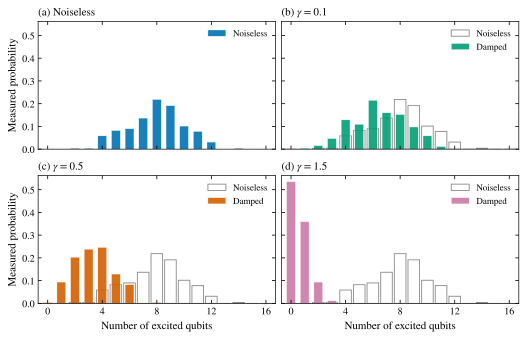

In [6]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.constrained_layout.use": True,
    "savefig.dpi": 180,
})
excitation_number = np.arange(num_qubits + 1)
colors = ["#0072B2", "#009E73", "#D55E00", "#CC79A7"]
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.6), sharex=True, sharey=True)
for ax, rate, probability, color, panel in zip(
    axes.flat, rates, probabilities, colors, "abcd", strict=True,
):
    if rate != 0:
        ax.bar(excitation_number, probabilities[0], width=0.85,
               facecolor="none", edgecolor="0.55", linewidth=0.9, label="Noiseless")
    ax.bar(excitation_number, probability, width=0.65, color=color,
           edgecolor="white", linewidth=0.4, alpha=0.9,
           label="Noiseless" if rate == 0 else "Damped")
    label = "Noiseless" if rate == 0 else rf"$\gamma={rate:g}$"
    ax.set_title(f"({panel}) {label}", loc="left", fontsize=11)
    ax.set(xlim=(-0.7, num_qubits + 0.7), xticks=np.arange(0, num_qubits + 1, 4))
    ax.legend(loc="upper right")
for ax in axes[-1]:
    ax.set_xlabel("Number of excited qubits")
for ax in axes[:, 0]:
    ax.set_ylabel("Measured probability")
plt.show()

**Readout shifts toward fewer excitations as damping increases.** Each panel
contains 256 shots from the same 16-qubit circuit. The noiseless distribution is
centered near eight excitations, while strong damping concentrates probability
near zero. The baseline outlines use the same samples in all panels.

Without noise, each qubit has excitation probability $1/2$, so the excitation
number follows a binomial distribution. The graph state's phases do not appear
in this measurement basis. A matching histogram alone therefore cannot verify
that the intended entangled state was prepared.

With noise, the shift measures excitation loss during the CZ gates. Different
bitstrings can have the same excitation number, so use `counts` or site-resolved
observables when the spatial distribution matters. For a bin of probability $p$,
independent shots have sampling uncertainty of order
$\sqrt{p(1-p)/\mathtt{shots}}$. Increase `shots` to reduce these fluctuations;
use tighter presets separately to check numerical error.

## Other measurement workflows

To obtain expectation values instead of counts, supply `observables` on
`DigitalSimParams`; see {doc}`circuit_observables`. You can request both outputs
in one call. In a noisy combined run, `num_traj` sets the observable ensemble,
and YAQS distributes the total `shots` across those trajectories. Multiple shots
from one trajectory share its noise history, so their uncertainty differs from
independent one-shot trajectories.

You can pass an OpenQASM source string or file path to `Simulator.run` in place
of a Qiskit circuit. OpenQASM 3 requires the `qasm3` extra. See
{doc}`circuit_observables` for an executable example, mid-circuit observable
checkpoints, and gate-application modes.

## Related topics

- {doc}`simulation_parameters` — sampling budgets and accuracy presets
- {doc}`realistic_noise_models` — other channels, custom operators, and disorder
- {ref}`circuit-custom-gates` — custom unitaries and gate translation
- {doc}`equivalence_checking` — compare circuit behavior